In [11]:
import pandas as pd
import numpy as np
df = pd.read_csv("Troop_stats.csv", index_col=0).T
df

,Housing space,Movement speed,Attack speed (Hertz),Range (tiles),Damage radius (tiles),Damage per attack,Hitpoints,Ability to attack air
Barbarian,1.0,16.0,1.000000,0.40,0.0,48.00,290.0,0.0
Archer,1.0,24.0,1.000000,3.50,0.0,40.00,68.0,1.0
Giant,5.0,12.0,0.500000,1.00,0.0,188.00,2400.0,0.0
Goblin,1.0,32.0,1.000000,0.40,0.0,144.00,146.0,0.0
Wall Breaker,2.0,24.0,1.000000,1.00,2.0,110.00,150.0,0.0
Balloon,5.0,10.0,0.333333,0.50,1.2,870.00,1140.0,0.0
Wizard,4.0,16.0,0.666667,3.00,0.3,412.50,290.0,1.0
Healer,14.0,16.0,1.428571,5.00,1.5,0.00,1900.0,0.0
Dragon,20.0,16.0,0.800000,3.00,0.3,487.50,5300.0,1.0
P.E.K.K.A,25.0,16.0,0.555556,0.80,0.0,1458.00,7700.0,0.0


In [12]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

scaled_df = std_scaler.fit_transform(df)

In [13]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
score = pca.fit_transform(scaled_df)
sum(pca.explained_variance_ratio_)

np.float64(0.5681240439359501)

In [14]:
pcs = np.array(pca.components_) # (n_comp, n_features)

df_pc = pd.DataFrame(pcs, columns=df.columns[0:])
df_pc.index = [f"{c} Principal Component" for c in['First', 'Second']]
df_pc.style\
    .background_gradient(cmap='bwr_r', axis=None)\
    .format("{:.2}")

,Housing space,Movement speed,Attack speed (Hertz),Range (tiles),Damage radius (tiles),Damage per attack,Hitpoints,Ability to attack air
First Principal Component,0.47,-0.39,-0.43,-0.16,0.25,0.34,0.48,-0.039
Second Principal Component,0.24,-0.082,0.28,0.65,0.18,0.21,-0.026,0.6


In [15]:
df_scores = pd.DataFrame(score, columns=['First Principal Component','Second Principal Component'], index = df.index)
df_scores.sort_values(by=['First Principal Component'])

,First Principal Component,Second Principal Component
Headhunter,-2.608681,0.331475
Minion,-2.463080,0.648481
Archer,-2.167199,1.014482
Goblin,-2.123139,-1.616392
Barbarian,-1.272022,-1.479818
Hog Rider,-1.267641,-1.312201
Miner,-1.114962,-1.734521
Witch,-1.109667,2.185606
Wall Breaker,-1.038272,-0.775759
Healer,-0.992782,1.428378


In [16]:
df_scores.sort_values(by=['Second Principal Component'])

,First Principal Component,Second Principal Component
Miner,-1.114962,-1.734521
Goblin,-2.123139,-1.616392
Barbarian,-1.272022,-1.479818
Giant,0.116117,-1.426492
Hog Rider,-1.267641,-1.312201
Ice Golem,0.865834,-1.308731
Valkyrie,0.159062,-1.286660
Root Rider,1.347390,-1.182944
Lava Hound,1.544363,-1.068035
Balloon,1.362790,-1.056258


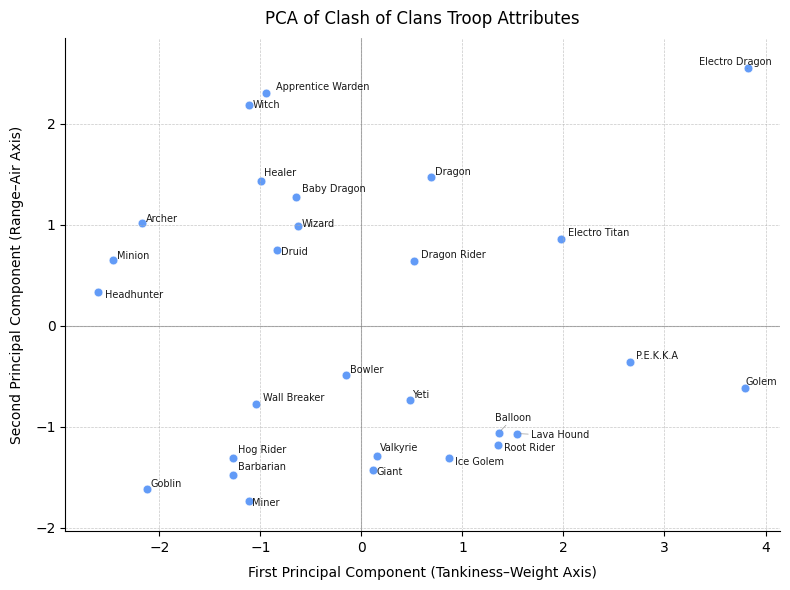

In [18]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

plt.figure(figsize=(8, 6))

# Base scatter
plt.scatter(df_scores.iloc[:, 0],
            df_scores.iloc[:, 1],
            color="#3B82F6",
            s=40,
            alpha=0.8,
            edgecolors="white",
            linewidth=0.6)

# Create all annotation objects
texts = []
for i, txt in enumerate(df_scores.index):
    texts.append(
        plt.text(df_scores.iloc[i, 0],
                 df_scores.iloc[i, 1],
                 txt,
                 fontsize=7,
                 alpha=0.9)
    )

# Auto-adjust to reduce overlaps
adjust_text(
    texts,
    only_move={'points': 'y', 'texts': 'y'},  # mostly vertical nudges
    arrowprops=dict(arrowstyle='-', color='grey', lw=0.4)
)

# Styling
plt.xlabel("First Principal Component (Tankiness–Weight Axis)", fontsize=10, labelpad=8)
plt.ylabel("Second Principal Component (Range–Air Axis)", fontsize=10, labelpad=8)
plt.title("PCA of Clash of Clans Troop Attributes", fontsize=12, pad=10)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.axhline(0, color="grey", linewidth=0.8, alpha=0.6)
plt.axvline(0, color="grey", linewidth=0.8, alpha=0.6)
plt.axis('equal')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()